# Base 05 — Microsoft Stock (MSFT)

Pipeline completo da série de abertura da Microsoft: documentação, EDA, limpeza, STL, features sem vazamento, tuning temporal, walk-forward, MAE, resíduos e interpretação.

**Execução:** o GridSearch temporal é pesado (SARIMAX com dezenas/centenas de configurações). Rode *Restart & Run All* neste computador; os outputs ainda não foram gerados nesta versão.

In [6]:
from pathlib import Path
from datetime import datetime, timezone
import json
import pickle
import time
import warnings

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import sklearn
import statsmodels
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

BASE_ID = "base_05"
RANDOM_STATE = 42
DATA_DIR = Path("../data") / BASE_ID
ARTIFACT_DIR = Path("../artifacts") / BASE_ID
RAW_FILE = DATA_DIR / "Microsoft_Stock.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

assert RAW_FILE.exists(), f"Arquivo raw ausente: {RAW_FILE}"
print({
    "python": __import__("sys").version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "matplotlib": matplotlib.__version__,
    "pyarrow": pyarrow.__version__,
})

{'python': '3.11.9', 'numpy': '1.26.4', 'pandas': '2.2.2', 'sklearn': '1.5.2', 'statsmodels': '0.14.5', 'matplotlib': '3.10.0', 'pyarrow': '19.0.1'}


## A–C. Documentação, EDA e limpeza

O arquivo contém preços diários de pregões da Microsoft entre 2015-04-01 e 2021-03-31. O alvo é `Open`, em USD. A frequência é uma sequência de sessões da bolsa dos EUA, não dias corridos nem simplesmente dias úteis federais.

| Coluna | Tipo | Significado | Papel | `availability` |
|---|---|---|---|---|
| `Date` | datetime | data/hora registrada para o pregão | índice | `known_ahead` |
| `Open` | float | preço de abertura (USD) | alvo | — |
| `High` | float | máxima (USD) | externa | `lag_only` |
| `Low` | float | mínima (USD) | externa | `lag_only` |
| `Close` | float | fechamento (USD) | externa | `lag_only` |
| `Volume` | int | volume negociado | externa | `lag_only` |

Na origem ao fim do pregão `t`, somente valores observados até `t` (incluindo o `Close` de `t`) são usados para prever a abertura do próximo pregão. Valores OHLCV do pregão previsto são proibidos.

,value
rows,1511
start,2015-04-01 00:00:00
end,2021-03-31 00:00:00
missing_total,0
duplicate_dates,0
weekend_rows,0
nonpositive_prices,0
negative_volume,0
ohlc_violations,0



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\miguelaraujo-ieg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


,metric,value
0,expected_xnys_sessions,1511
1,observed_rows,1511
2,missing_xnys_sessions,0
3,extra_non_xnys_dates,0


Retornos fora de 3×IQR: 16; preservados.


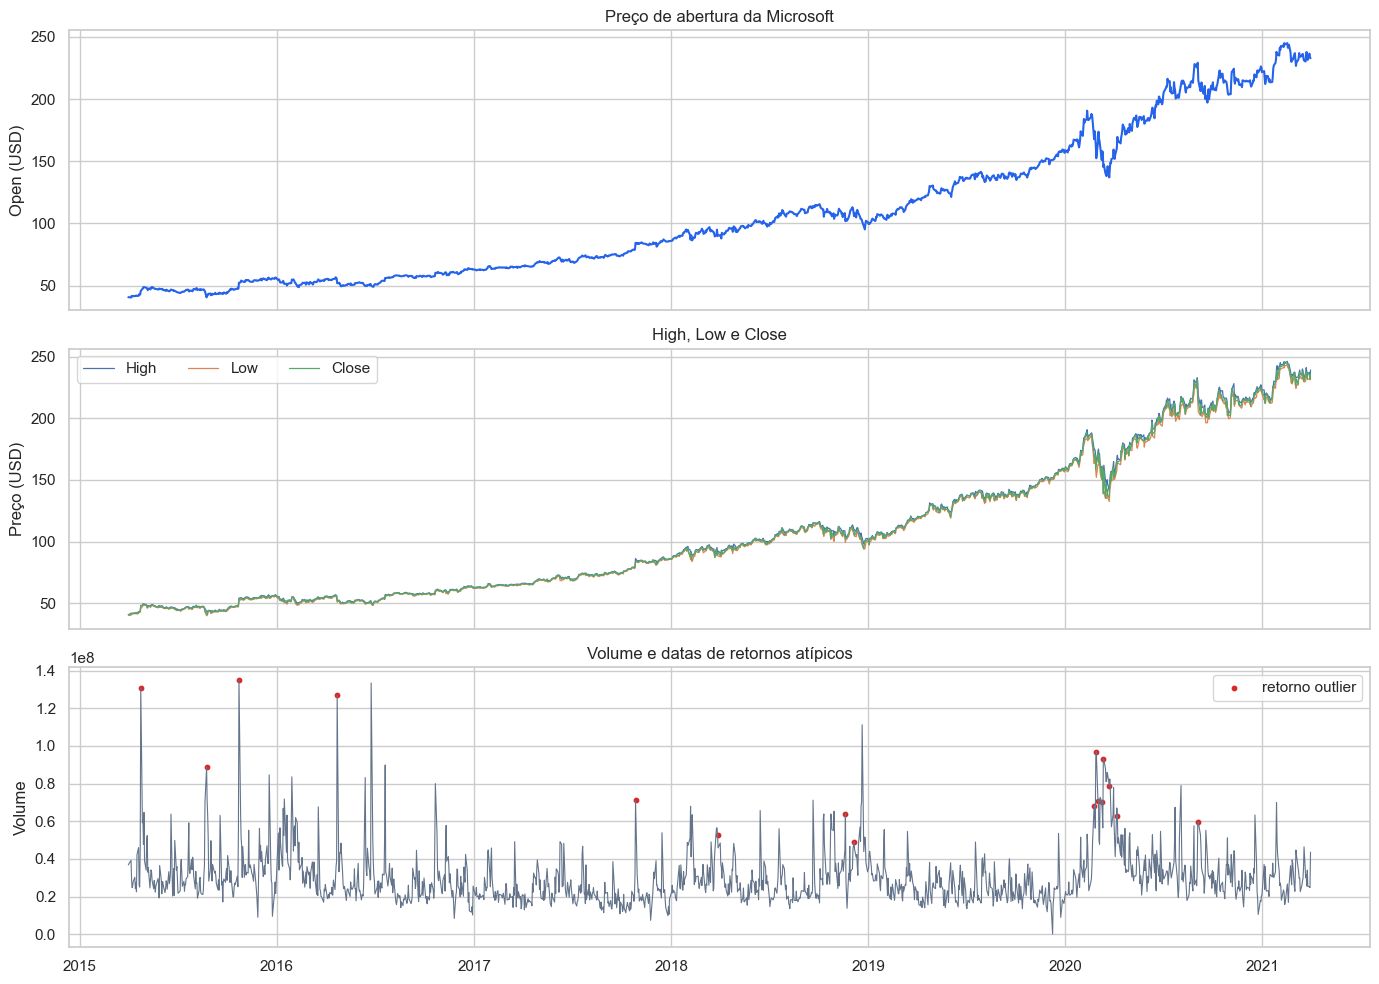

Limpo salvo sem imputação ou remoção: (1511, 6)


In [7]:
raw = pd.read_csv(RAW_FILE)
expected_columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
assert raw.columns.tolist() == expected_columns

df = raw.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="raise").dt.normalize()
df = df.sort_values("Date").reset_index(drop=True)

integrity = {
    "rows": len(df),
    "start": df["Date"].min(),
    "end": df["Date"].max(),
    "missing_total": int(df.isna().sum().sum()),
    "duplicate_dates": int(df["Date"].duplicated().sum()),
    "weekend_rows": int((df["Date"].dt.dayofweek >= 5).sum()),
    "nonpositive_prices": int((df[["Open", "High", "Low", "Close"]] <= 0).sum().sum()),
    "negative_volume": int((df["Volume"] < 0).sum()),
    "ohlc_violations": int(
        ((df["Low"] > df[["Open", "Close"]].min(axis=1))
         | (df["High"] < df[["Open", "Close"]].max(axis=1))).sum()
    ),
}
display(pd.Series(integrity, name="value").to_frame())
assert integrity["rows"] == 1511
assert all(integrity[k] == 0 for k in [
    "missing_total", "duplicate_dates", "weekend_rows",
    "nonpositive_prices", "negative_volume", "ohlc_violations"
])

# Calendário oficial de sessões XNYS para distinguir feriados de possíveis falhas.4
!pip install exchange_calendars
import exchange_calendars as xcals
xnys = xcals.get_calendar("XNYS")
expected_sessions = xnys.sessions_in_range(df["Date"].min(), df["Date"].max())
expected_dates = pd.DatetimeIndex(expected_sessions).tz_localize(None).normalize()
observed_dates = pd.DatetimeIndex(df["Date"])
missing_sessions = expected_dates.difference(observed_dates)
extra_sessions = observed_dates.difference(expected_dates)
calendar_check = pd.DataFrame({
    "metric": ["expected_xnys_sessions", "observed_rows", "missing_xnys_sessions", "extra_non_xnys_dates"],
    "value": [len(expected_dates), len(observed_dates), len(missing_sessions), len(extra_sessions)],
})
display(calendar_check)
if len(missing_sessions):
    print("Sessões XNYS ausentes:", missing_sessions.strftime("%Y-%m-%d").tolist())
if len(extra_sessions):
    print("Datas fora do calendário XNYS:", extra_sessions.strftime("%Y-%m-%d").tolist())

# Outliers informativos em retornos: não removidos, pois podem ser movimentos reais de mercado.
returns = df["Open"].pct_change()
q1, q3 = returns.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (returns < q1 - 3 * iqr) | (returns > q3 + 3 * iqr)
print(f"Retornos fora de 3×IQR: {int(outlier_mask.sum())}; preservados.")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df["Date"], df["Open"], color="#2563eb", linewidth=1.5)
axes[0].set(title="Preço de abertura da Microsoft", ylabel="Open (USD)")
for col in ["High", "Low", "Close"]:
    axes[1].plot(df["Date"], df[col], label=col, linewidth=0.9)
axes[1].legend(ncol=3)
axes[1].set(ylabel="Preço (USD)", title="High, Low e Close")
axes[2].plot(df["Date"], df["Volume"], color="#64748b", linewidth=0.8)
axes[2].scatter(df.loc[outlier_mask, "Date"], df.loc[outlier_mask, "Volume"], s=10, color="#dc2626", label="retorno outlier")
axes[2].legend()
axes[2].set(ylabel="Volume", title="Volume e datas de retornos atípicos")
plt.tight_layout()
plt.show()

cleaned = df.copy()
cleaned.to_csv(DATA_DIR / f"cleaned_{BASE_ID}.csv", index=False)
assert (DATA_DIR / f"cleaned_{BASE_ID}.csv").exists()
print("Limpo salvo sem imputação ou remoção:", cleaned.shape)

### Decisões de limpeza

| Etapa | Decisão | Justificativa |
|---|---|---|
| Parse de `Date` | `pd.to_datetime`, ordenação e normalização da hora | 16:00 é o carimbo do CSV; a série é diária de pregões, não intradiária |
| Frequência | sequência observada validada contra XNYS | não inserir sábados, domingos ou feriados |
| Missing | nenhuma imputação | não há valores ausentes no raw |
| Outliers | preservar | saltos em retornos podem ser eventos reais; são sinalizados, não apagados |
| Alvo | nível em USD | mantém MAE diretamente interpretável |

O raw não é regravado. A série limpa apenas normaliza a data e preserva todas as 1.511 observações.

## D. STL, ACF/PACF e força da sazonalidade

O teste final não entra nestes diagnósticos. No desenvolvimento, comparamos a força da sazonalidade para `m ∈ {5, 10, 21, 63}` (semana, quinzena, mês de pregões, trimestre). O `m=5` permanece candidato de domínio; os modelos também recebem `m=21` no GridSearch.

ACF/PACF são plotados no nível, na primeira diferença e nos retornos, para orientar `d`, `D` e as ordens `(p, q)`.

{'development_end': Timestamp('2020-12-29 00:00:00'), 'test_start': Timestamp('2020-12-30 00:00:00'), 'test_observations': 63}


,series,adf_stat,p_value,lags,n,crit_5pct,stationary_5pct
0,Open (nível),1.288828,9.965456e-01,11,1436,-2.863555,False
1,Open (1ª diferença),-9.397556,6.314242e-16,24,1422,-2.863575,True
2,Open (retorno),-30.414739,0.000000e+00,1,1445,-2.863542,True


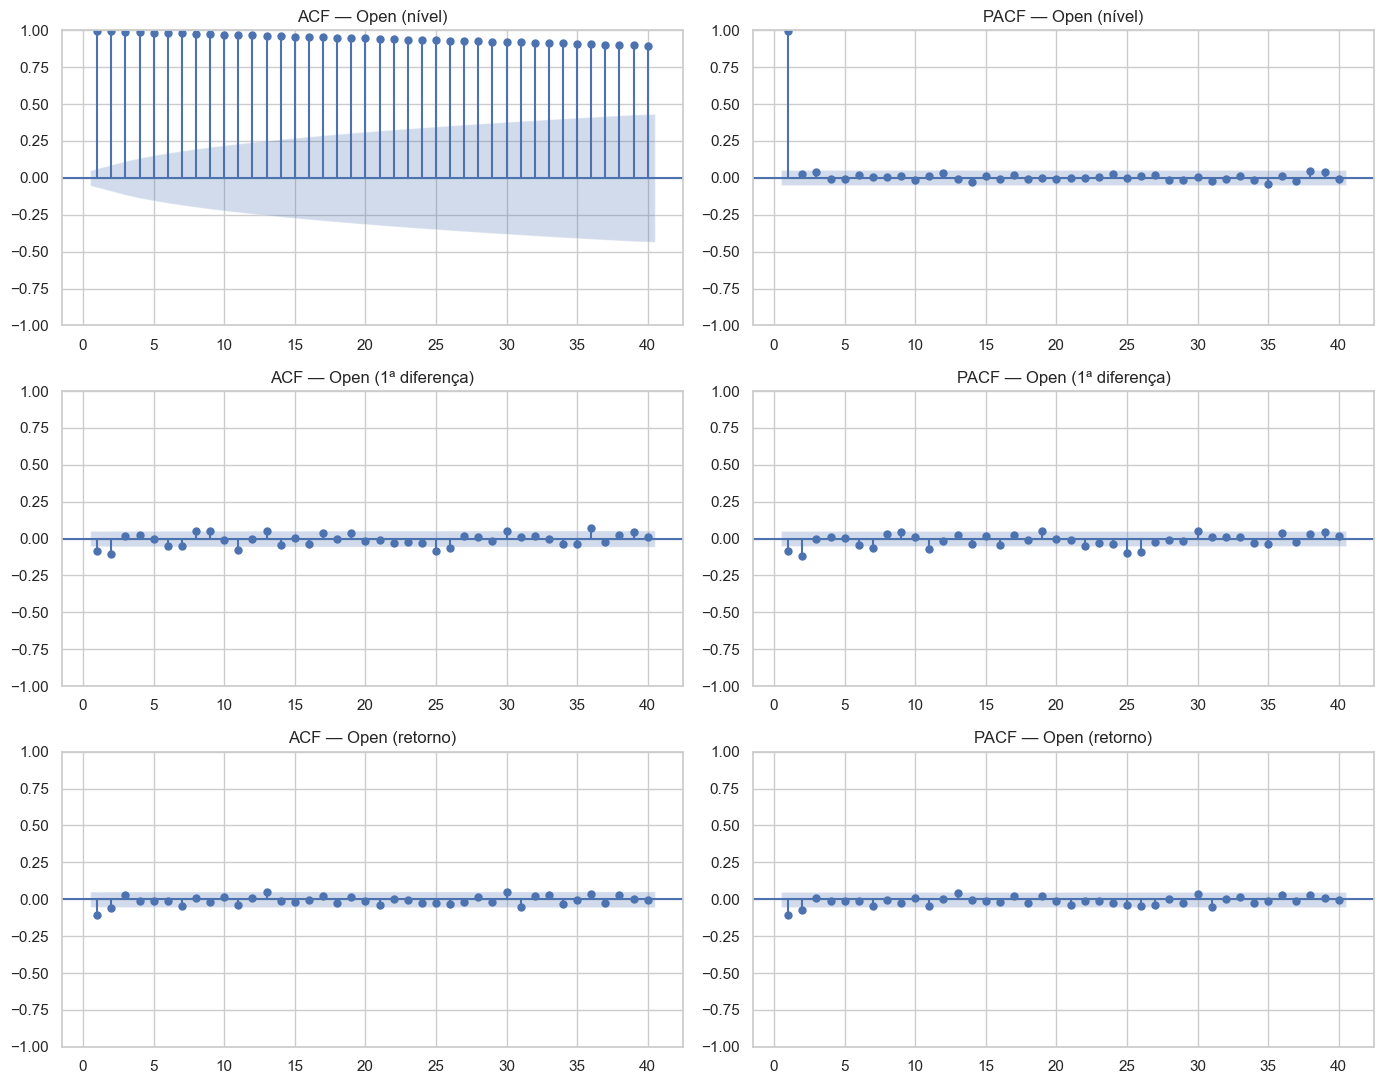

,m,seasonality_strength
3,63,0.001738
0,5,0.000000
1,10,0.000000
2,21,0.000000


Força da sazonalidade no desenvolvimento (m=5, domínio): 0.0000
Maior Fs no desenvolvimento: m=63


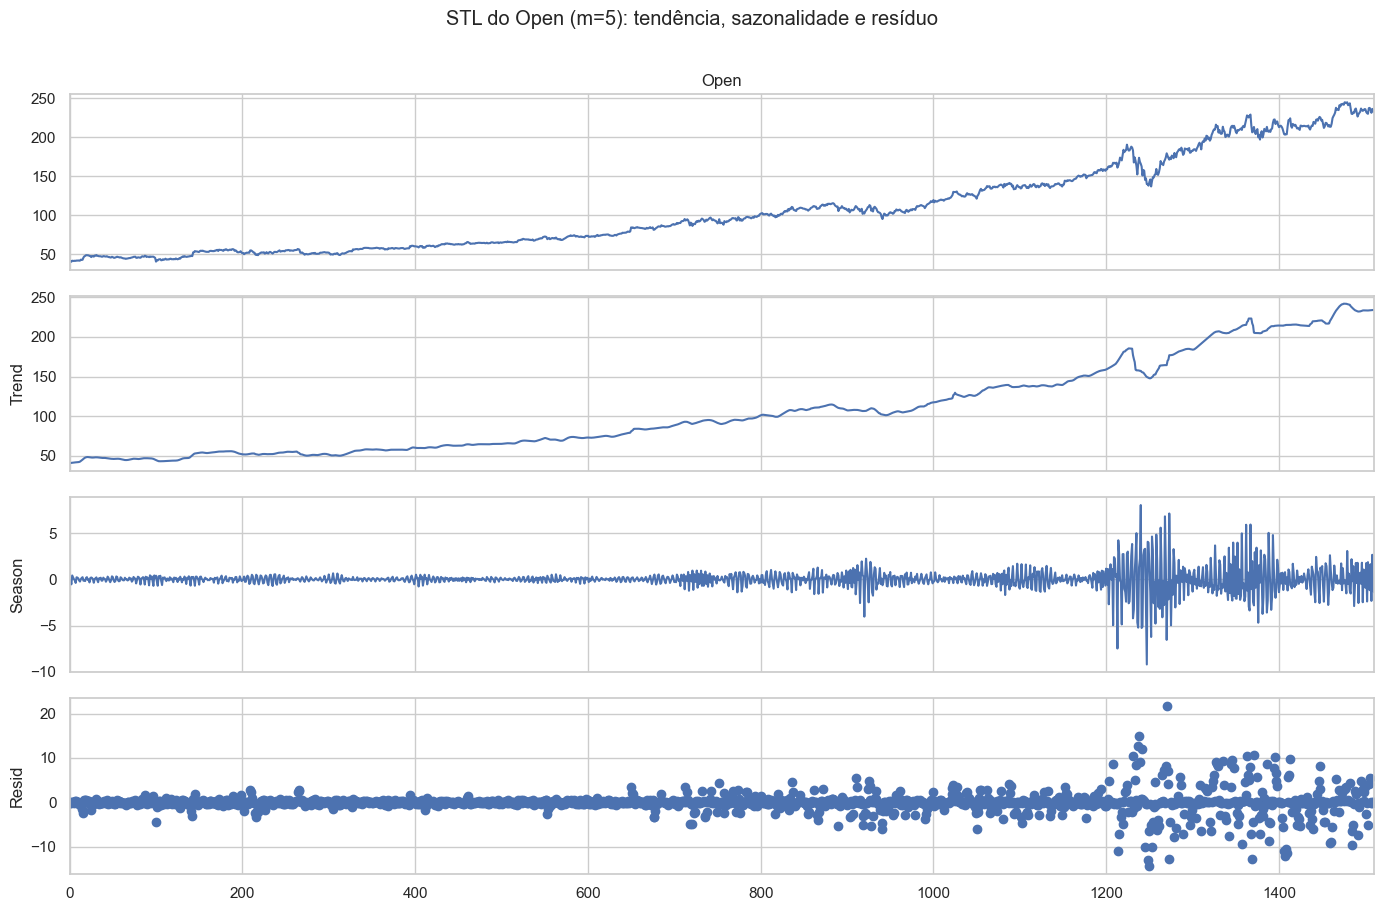

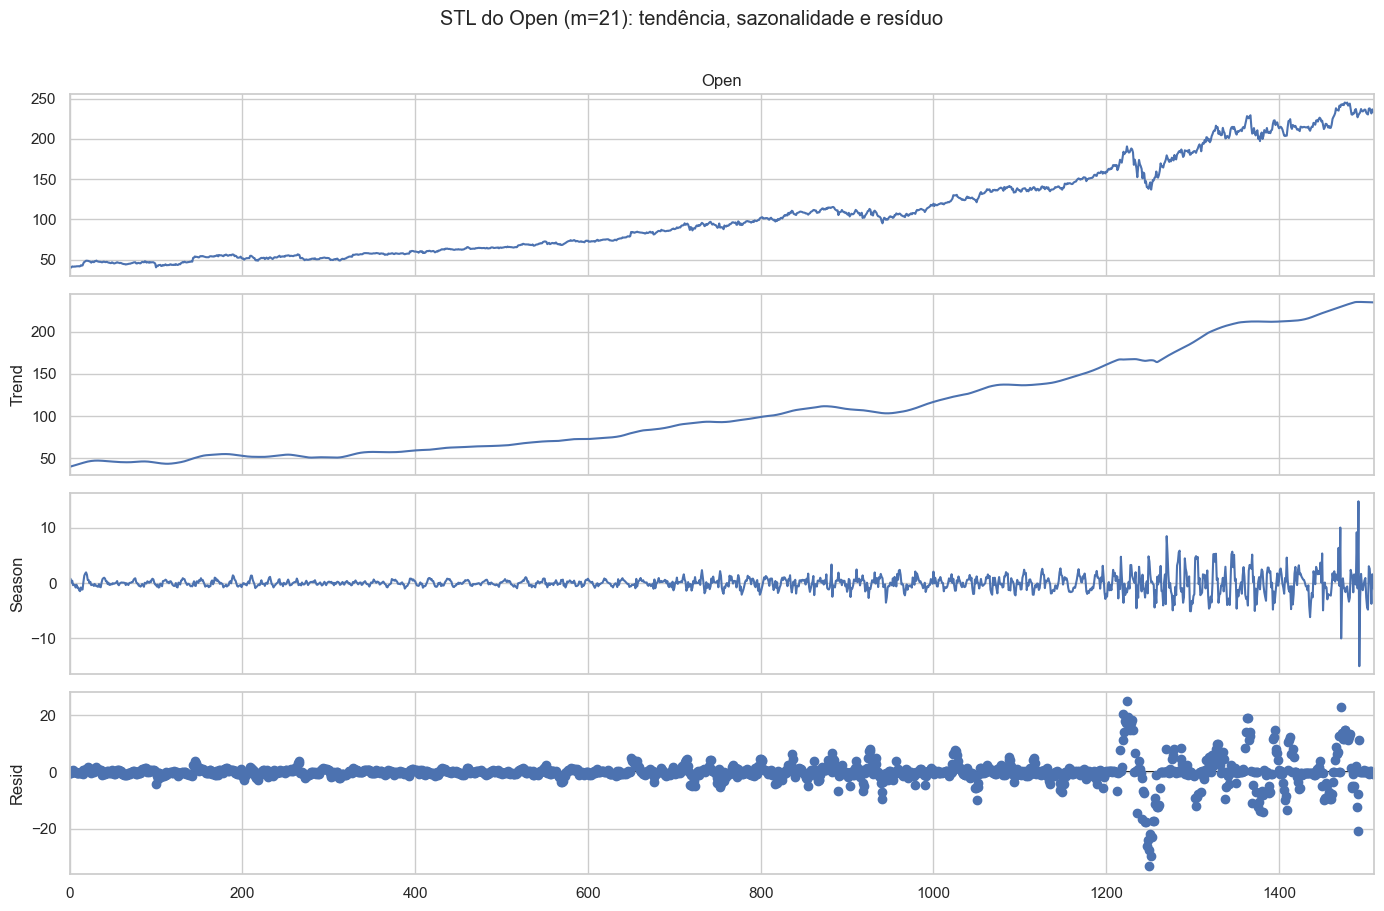

In [8]:
HORIZON = 1
ORIGIN_STEP = 1
TRAIN_MIN_OBS = 252
TEST_OBS = 63
SEASONAL_PERIOD = 5
PERIOD_CANDIDATES = [5, 10, 21, 63]

test_start_idx = len(cleaned) - TEST_OBS
development_end = cleaned.loc[test_start_idx - 1, "Date"]
test_start = cleaned.loc[test_start_idx, "Date"]
print({"development_end": development_end, "test_start": test_start, "test_observations": TEST_OBS})

development_open = cleaned.loc[:test_start_idx - 1, "Open"].reset_index(drop=True)
dev_index = cleaned.loc[:test_start_idx - 1, "Date"]


def adf_summary(series, name):
    series = pd.Series(series).dropna()
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(series, autolag="AIC")
    return {
        "series": name,
        "adf_stat": float(stat),
        "p_value": float(pvalue),
        "lags": int(usedlag),
        "n": int(nobs),
        "crit_5pct": float(crit["5%"]),
        "stationary_5pct": pvalue < 0.05,
    }


level = development_open
diff1 = development_open.diff().dropna()
returns = development_open.pct_change().dropna()
display(pd.DataFrame([
    adf_summary(level, "Open (nível)"),
    adf_summary(diff1, "Open (1ª diferença)"),
    adf_summary(returns, "Open (retorno)"),
]))

acf_lags = min(40, max(10, len(level) // 8))
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for row, (series, title) in enumerate([
    (level, "Open (nível)"),
    (diff1, "Open (1ª diferença)"),
    (returns, "Open (retorno)"),
]):
    plot_acf(series, lags=acf_lags, ax=axes[row, 0], zero=False)
    plot_pacf(series, lags=acf_lags, ax=axes[row, 1], zero=False, method="ywm")
    axes[row, 0].set_title(f"ACF — {title}")
    axes[row, 1].set_title(f"PACF — {title}")
plt.tight_layout()
plt.show()

seasonality_rows = []
stl_by_period = {}
for period in PERIOD_CANDIDATES:
    fitted = STL(development_open, period=period, robust=True).fit()
    strength = max(
        0.0,
        1.0 - np.var(fitted.resid, ddof=1) / np.var(fitted.seasonal + fitted.resid, ddof=1),
    )
    stl_by_period[period] = fitted
    seasonality_rows.append({"m": period, "seasonality_strength": strength})
seasonality_table = pd.DataFrame(seasonality_rows).sort_values("seasonality_strength", ascending=False)
display(seasonality_table)
best_m = int(seasonality_table.iloc[0]["m"])
seasonality_strength = float(seasonality_table.loc[seasonality_table["m"] == SEASONAL_PERIOD, "seasonality_strength"].iloc[0])
print(f"Força da sazonalidade no desenvolvimento (m=5, domínio): {seasonality_strength:.4f}")
print(f"Maior Fs no desenvolvimento: m={best_m}")

for period in [SEASONAL_PERIOD, 21]:
    fig = STL(cleaned["Open"], period=period, robust=True).fit().plot()
    fig.set_size_inches(14, 9)
    plt.suptitle(f"STL do Open (m={period}): tendência, sazonalidade e resíduo", y=1.01)
    plt.tight_layout()
    plt.show()


A tendência é predominantemente crescente no período, com aceleração após 2019 e ruptura/maior volatilidade ao redor de 2020. ACF lenta no nível e ADF não estacionário apontam para diferenciação; a primeira diferença e os retornos devem perder essa persistência. O componente sazonal semanal costuma ser pequeno frente à tendência; a tabela de $F_s$ no desenvolvimento compara `m` candidatos sem olhar o teste. O resíduo concentra choques de mercado.


## E. Feature engineering e contrato anti-vazamento

Features finais comuns ao Random Forest e Elastic Net:

- alvo: `open_lag_1`, `open_lag_5`;
- externas: `close_lag_1`, `high_lag_1`, `low_lag_1`, `log_volume_lag_1`;
- janelas fechadas na origem: média e desvio do `Open` em 5 e 21 pregões; média e desvio de retornos do `Open` em 5 e 21 pregões;
- calendário da data prevista: mês, fim de mês, seno/cosseno do dia da semana e do dia do ano.

As primeiras linhas incompletas são descartadas. Não há imputação. Como `h=1`, `shift(1)` na linha da data prevista referencia exatamente a origem. O `close_lag_1` é o fechamento do pregão de origem, já conhecido ao prever a abertura seguinte.

In [9]:
def build_samples(frame):
    x = frame.copy().set_index("Date")
    open_px = x["Open"]
    ret = open_px.pct_change()
    samples = pd.DataFrame(index=x.index)
    samples["origin_date"] = samples.index.to_series().shift(1)
    samples["forecast_date"] = samples.index
    samples["horizon_step"] = 1
    samples["open_lag_1"] = open_px.shift(1)
    samples["open_lag_5"] = open_px.shift(5)
    samples["close_lag_1"] = x["Close"].shift(1)
    samples["high_lag_1"] = x["High"].shift(1)
    samples["low_lag_1"] = x["Low"].shift(1)
    samples["log_volume_lag_1"] = np.log1p(x["Volume"].shift(1))
    for window in [5, 21]:
        samples[f"open_mean_{window}"] = open_px.shift(1).rolling(window).mean()
        samples[f"open_std_{window}"] = open_px.shift(1).rolling(window).std()
        samples[f"return_mean_{window}"] = ret.shift(1).rolling(window).mean()
        samples[f"return_std_{window}"] = ret.shift(1).rolling(window).std()
    forecast_dates = pd.Series(samples.index, index=samples.index)
    dow = forecast_dates.dt.dayofweek
    doy = forecast_dates.dt.dayofyear
    samples["month"] = forecast_dates.dt.month
    samples["is_month_end"] = forecast_dates.dt.is_month_end.astype(int)
    samples["dow_sin"] = np.sin(2 * np.pi * dow / 5)
    samples["dow_cos"] = np.cos(2 * np.pi * dow / 5)
    samples["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    samples["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    samples["observed_source_max_date"] = samples["origin_date"]
    samples["target"] = open_px
    return samples.dropna().reset_index(drop=True)

samples = build_samples(cleaned)
key_cols = ["origin_date", "forecast_date", "horizon_step"]
audit_cols = ["observed_source_max_date"]
feature_cols = [
    c for c in samples.columns
    if c not in key_cols + audit_cols + ["target"]
]
assert (samples["observed_source_max_date"] <= samples["origin_date"]).all()
assert (samples["origin_date"] < samples["forecast_date"]).all()
assert samples[key_cols].duplicated().sum() == 0
assert not samples[feature_cols + ["target"]].isna().any().any()

samples.to_parquet(DATA_DIR / f"features_{BASE_ID}.parquet", index=False)
roundtrip = pd.read_parquet(DATA_DIR / f"features_{BASE_ID}.parquet")
assert roundtrip.shape == samples.shape
print(f"{len(feature_cols)} features; {len(samples)} amostras; anti-leakage validado.")
display(samples.head(3))

20 features; 1489 amostras; anti-leakage validado.


,origin_date,forecast_date,horizon_step,open_lag_1,open_lag_5,close_lag_1,high_lag_1,low_lag_1,log_volume_lag_1,open_mean_5,...,return_mean_21,return_std_21,month,is_month_end,dow_sin,dow_cos,doy_sin,doy_cos,observed_source_max_date,target
0,2015-05-01,2015-05-04,1,48.58,47.23,48.66,48.88,48.40,17.477464,48.202,...,0.008739,0.018417,5,0,0.000000,1.000000,0.846029,-0.533137,2015-05-01,48.37
1,2015-05-04,2015-05-05,1,48.37,47.78,48.24,48.87,48.18,17.343032,48.430,...,0.008462,0.018574,5,0,0.951057,0.309017,0.836733,-0.547611,2015-05-04,47.82
2,2015-05-05,2015-05-06,1,47.82,48.72,47.60,48.16,47.31,17.734890,48.438,...,0.008296,0.018743,5,0,0.587785,-0.809017,0.827189,-0.561923,2015-05-05,47.57


Checklist anti-leakage:

- [x] toda feature observada possui `observed_source_max_date <= origin_date`;
- [x] OHLCV do pregão previsto não é usado;
- [x] calendário usa apenas `forecast_date` e é conhecido antecipadamente;
- [x] scaler do Elastic Net fica dentro de `Pipeline` e é ajustado em cada treino;
- [x] RF e Elastic Net usam exatamente `feature_cols`;
- [x] teste final foi separado antes do tuning.

## F. GridSearch temporal e motor walk-forward

O desenvolvimento termina antes dos últimos 63 pregões. **O teste final nunca entra na busca.**

- **SARIMAX:** grid de `(p,d,q)`, `(P,D,Q)` e `m ∈ {5, 21}` em origens expansivas.
- **Holt-Winters:** grid de tendência (`add`/`mul`/nenhuma), amortecimento, sazonalidade (`add`/`mul`/nenhuma) e `m ∈ {5, 21}`.
- **Random Forest e Elastic Net:** `GridSearchCV` com `TimeSeriesSplit` (5 folds) e `scoring='neg_mean_absolute_error'`.

Esta célula é pesada (centenas de ajustes SARIMAX). Rode em máquina com tempo; os hiperparâmetros escolhidos são congelados antes do walk-forward de teste.

In [10]:
development = samples[samples["forecast_date"] < test_start].reset_index(drop=True)
test_samples = samples[samples["forecast_date"] >= test_start].reset_index(drop=True)
assert development["forecast_date"].max() <= development_end
assert test_samples["forecast_date"].min() == test_start
assert len(test_samples) == TEST_OBS

sarimax_features = ["close_lag_1", "log_volume_lag_1", "dow_sin", "dow_cos"]


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if obj is None or isinstance(obj, (str, bool, int, float)):
        return obj
    return str(obj)


def expanding_origins(n, count=4, validation_size=40):
    start = max(TRAIN_MIN_OBS, n - validation_size)
    return np.unique(np.linspace(start, n - 1, count, dtype=int))


def tune_stats_model(model_name, candidates):
    records = []
    origins = expanding_origins(len(development))
    n_candidates = len(candidates)
    print(f"{model_name}: {n_candidates} configurações × {len(origins)} origens")
    for i, params in enumerate(candidates, start=1):
        errors = []
        for idx in origins:
            train = development.iloc[:idx]
            valid = development.iloc[idx:idx + 1]
            try:
                if model_name == "sarimax":
                    seasonal_order = tuple(params["seasonal_order"])
                    fitted = SARIMAX(
                        train["target"],
                        exog=train[sarimax_features],
                        order=tuple(params["order"]),
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False, maxiter=75)
                    pred = fitted.forecast(1, exog=valid[sarimax_features]).iloc[0]
                else:
                    seasonal = params["seasonal"]
                    fitted = ExponentialSmoothing(
                        train["target"].to_numpy(),
                        trend=params["trend"],
                        damped_trend=params["damped_trend"],
                        seasonal=seasonal,
                        seasonal_periods=params["seasonal_periods"] if seasonal else None,
                        initialization_method="estimated",
                    ).fit(optimized=True)
                    pred = fitted.forecast(1)[0]
                errors.append(abs(valid["target"].iloc[0] - pred))
            except Exception:
                errors.append(np.inf)
        records.append({
            "params": jsonable(params),
            "validation_mae": float(np.mean(errors)),
            "n_failed_origins": int(np.isinf(errors).sum()),
        })
        if i % 25 == 0 or i == n_candidates:
            print(f"  {model_name} {i}/{n_candidates}")
    return sorted(records, key=lambda r: r["validation_mae"])


from itertools import product

sarimax_candidates = []
for order in product([0, 1, 2], [0, 1], [0, 1, 2]):
    sarimax_candidates.append({"order": order, "seasonal_order": (0, 0, 0, 5)})
    for seasonal_order in product([0, 1], [0, 1], [0, 1], [5, 21]):
        if seasonal_order[:3] == (0, 0, 0):
            continue
        sarimax_candidates.append({"order": order, "seasonal_order": seasonal_order})

hw_candidates = []
for trend in [None, "add", "mul"]:
    damped_options = [False] if trend is None else [False, True]
    for damped_trend in damped_options:
        hw_candidates.append({
            "trend": trend,
            "damped_trend": damped_trend,
            "seasonal": None,
            "seasonal_periods": None,
        })
        for seasonal, period in product(["add", "mul"], [5, 21]):
            hw_candidates.append({
                "trend": trend,
                "damped_trend": damped_trend,
                "seasonal": seasonal,
                "seasonal_periods": period,
            })

sarimax_search = tune_stats_model("sarimax", sarimax_candidates)
hw_search = tune_stats_model("holt_winters", hw_candidates)
sarimax_params = sarimax_search[0]["params"]
hw_params = hw_search[0]["params"]
if isinstance(sarimax_params["order"], list):
    sarimax_params["order"] = tuple(sarimax_params["order"])
if isinstance(sarimax_params["seasonal_order"], list):
    sarimax_params["seasonal_order"] = tuple(sarimax_params["seasonal_order"])

cv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [6, 12, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}
en_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
])
en_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

print("random_forest: GridSearchCV", np.prod([len(v) for v in rf_grid.values()]), "configs × 5 folds")
rf_gs = GridSearchCV(
    rf_base,
    rf_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
rf_gs.fit(development[feature_cols], development["target"])

print("elastic_net: GridSearchCV", np.prod([len(v) for v in en_grid.values()]), "configs × 5 folds")
en_gs = GridSearchCV(
    en_base,
    en_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
en_gs.fit(development[feature_cols], development["target"])

rf_params = rf_gs.best_params_
en_params = en_gs.best_params_


def sklearn_search_table(gs):
    cv_df = pd.DataFrame(gs.cv_results_)
    keep = ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    table = cv_df[keep].copy()
    table["validation_mae"] = -table["mean_test_score"]
    table = table.sort_values("rank_test_score")
    return [
        {"params": jsonable(row.params), "validation_mae": float(row.validation_mae), "rank": int(row.rank_test_score)}
        for row in table.itertuples(index=False)
    ]


rf_search = sklearn_search_table(rf_gs)
en_search = sklearn_search_table(en_gs)

searches = {
    "sarimax": (sarimax_search, sarimax_params),
    "holt_winters": (hw_search, hw_params),
    "random_forest": (rf_search, rf_params),
    "elastic_net": (en_search, en_params),
}
for model_name, (search, selected) in searches.items():
    payload = {
        "base_id": BASE_ID,
        "model": model_name,
        "method": (
            "expanding temporal GridSearch"
            if model_name in ["sarimax", "holt_winters"]
            else "GridSearchCV + TimeSeriesSplit(n_splits=5)"
        ),
        "tuning_end": str(development_end.date()),
        "test_start": str(test_start.date()),
        "n_candidates": len(search),
        "search_results": search[:30],
        "selected": jsonable(selected),
        "criterion": "menor MAE médio na validação temporal",
    }
    with open(DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json", "w") as f:
        json.dump(payload, f, indent=2)
    print(model_name, selected, "validation_mae=", round(search[0]["validation_mae"], 4))


sarimax: 270 configurações × 4 origens


  sarimax 25/270
  sarimax 50/270
  sarimax 75/270
  sarimax 100/270
  sarimax 125/270
  sarimax 150/270
  sarimax 175/270
  sarimax 200/270
  sarimax 225/270
  sarimax 250/270
  sarimax 270/270
holt_winters: 25 configurações × 4 origens
  holt_winters 25/25
random_forest: GridSearchCV 324 configs × 5 folds
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
elastic_net: GridSearchCV 36 configs × 5 folds
Fitting 5 folds for each of 36 candidates, totalling 180 fits
sarimax {'order': (1, 1, 0), 'seasonal_order': (1, 1, 1, 21)} validation_mae= 0.5569
holt_winters {'trend': 'mul', 'damped_trend': False, 'seasonal': 'mul', 'seasonal_periods': 21} validation_mae= 0.9572
random_forest {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100} validation_mae= 16.8488
elastic_net {'model__alpha': 0.01, 'model__l1_ratio': 1.0} validation_mae= 0.8388


In [11]:
def fit_predict_one(model_name, train, current):
    fit_start = time.perf_counter()
    if model_name == "sarimax":
        model = SARIMAX(
            train["target"],
            exog=train[sarimax_features],
            order=tuple(sarimax_params["order"]),
            seasonal_order=tuple(sarimax_params["seasonal_order"]),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=75)
    elif model_name == "holt_winters":
        model = ExponentialSmoothing(
            train["target"].to_numpy(),
            trend=hw_params["trend"],
            damped_trend=hw_params["damped_trend"],
            seasonal=hw_params["seasonal"],
            seasonal_periods=hw_params.get("seasonal_periods"),
            initialization_method="estimated",
        ).fit(optimized=True)
    elif model_name == "random_forest":
        model = clone(rf_base).set_params(**rf_params)
        model.fit(train[feature_cols], train["target"])
    else:
        model = clone(en_base).set_params(**en_params)
        model.fit(train[feature_cols], train["target"])
    fit_seconds = time.perf_counter() - fit_start
    pred_start = time.perf_counter()
    if model_name == "sarimax":
        y_pred = float(model.forecast(1, exog=current[sarimax_features].astype(float)).iloc[0])
    elif model_name == "holt_winters":
        y_pred = float(model.forecast(1)[0])
    else:
        y_pred = float(model.predict(current[feature_cols].astype(float))[0])
    predict_seconds = time.perf_counter() - pred_start
    return y_pred, fit_seconds, predict_seconds

model_names = ["sarimax", "holt_winters", "random_forest", "elastic_net"]
predictions = {}
for model_name in model_names:
    rows = []
    for _, current_row in test_samples.iterrows():
        current = current_row.to_frame().T
        origin = current_row["origin_date"]
        train = samples[samples["forecast_date"] <= origin]
        assert len(train) >= TRAIN_MIN_OBS
        assert train["forecast_date"].max() <= origin
        assert current_row["observed_source_max_date"] <= origin
        y_pred, fit_seconds, predict_seconds = fit_predict_one(model_name, train, current)
        rows.append({
            "origin_date": origin,
            "forecast_date": current_row["forecast_date"],
            "horizon_step": 1,
            "y_true": current_row["target"],
            "y_pred": y_pred,
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
        })
    pred_df = pd.DataFrame(rows)
    pred_df.to_csv(DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv", index=False)
    predictions[model_name] = pred_df
    print(model_name, len(pred_df), "previsões")

reference_keys = predictions[model_names[0]][key_cols].reset_index(drop=True)
for model_name in model_names[1:]:
    pd.testing.assert_frame_equal(reference_keys, predictions[model_name][key_cols].reset_index(drop=True))
assert len({len(v) for v in predictions.values()}) == 1
print("Conformidade: chaves OOS idênticas nos quatro modelos.")


sarimax 63 previsões
holt_winters 63 previsões
random_forest 63 previsões
elastic_net 63 previsões
Conformidade: chaves OOS idênticas nos quatro modelos.


## G. MAE, ranking e gráficos de avaliação

O MAE abaixo usa exclusivamente previsões fora da amostra do walk-forward. Os gráficos comparam Open observado vs previsto, a dispersão e o ranking. Não há agregação com outras bases.

,base_id,model,mae,rank,n_predictions
0,base_05,elastic_net,1.696697,1,63
1,base_05,sarimax,1.993968,2,63
2,base_05,random_forest,2.256058,3,63
3,base_05,holt_winters,2.651880,4,63


Vencedor nesta base: elastic_net


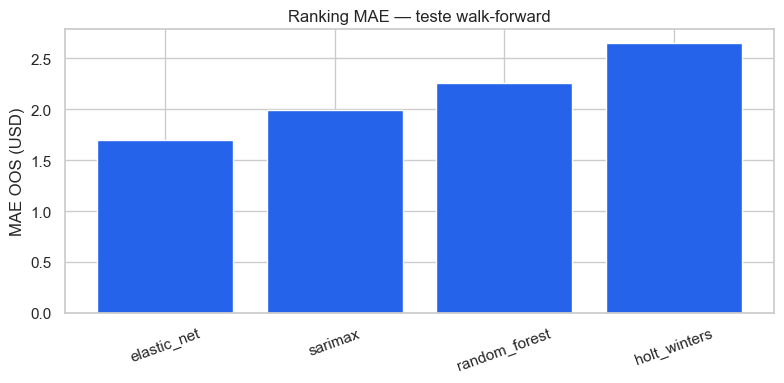

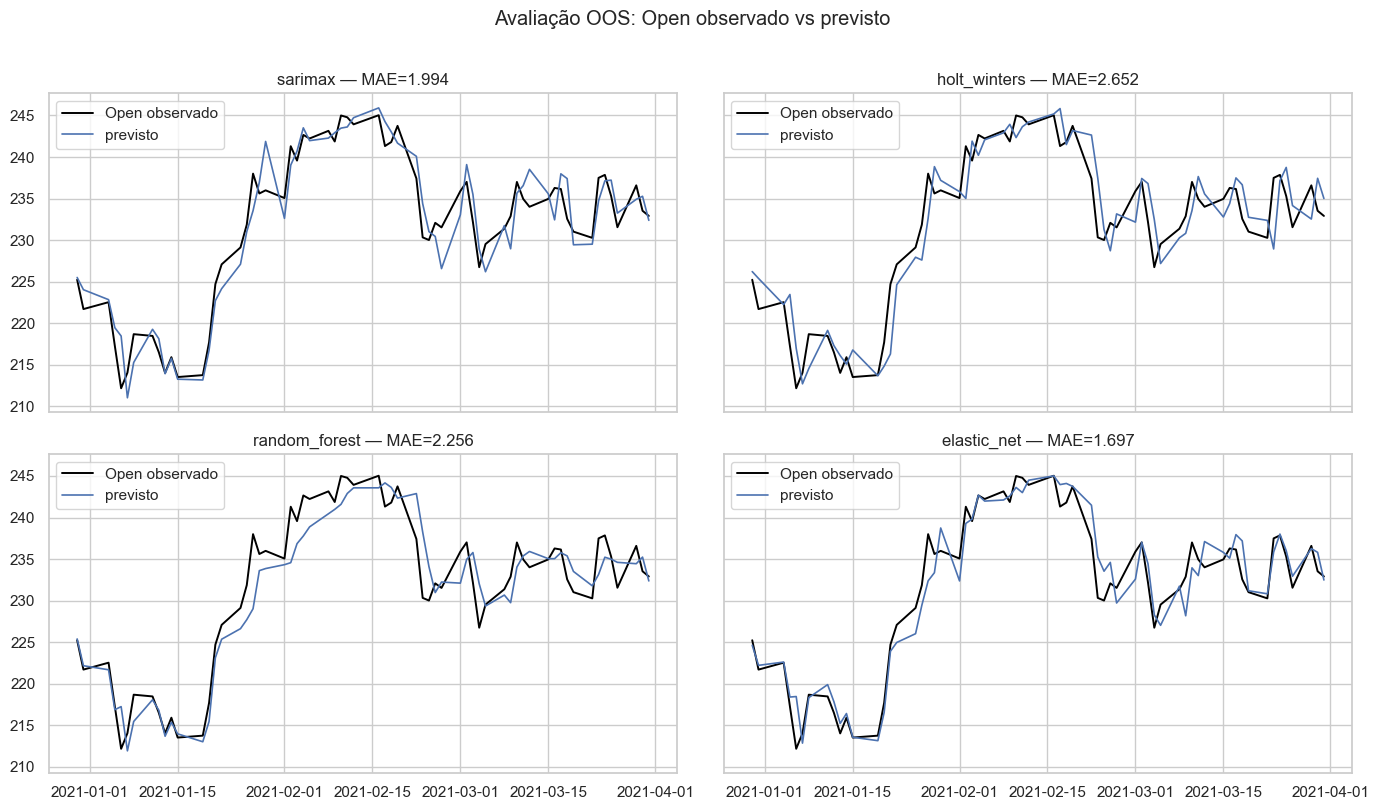

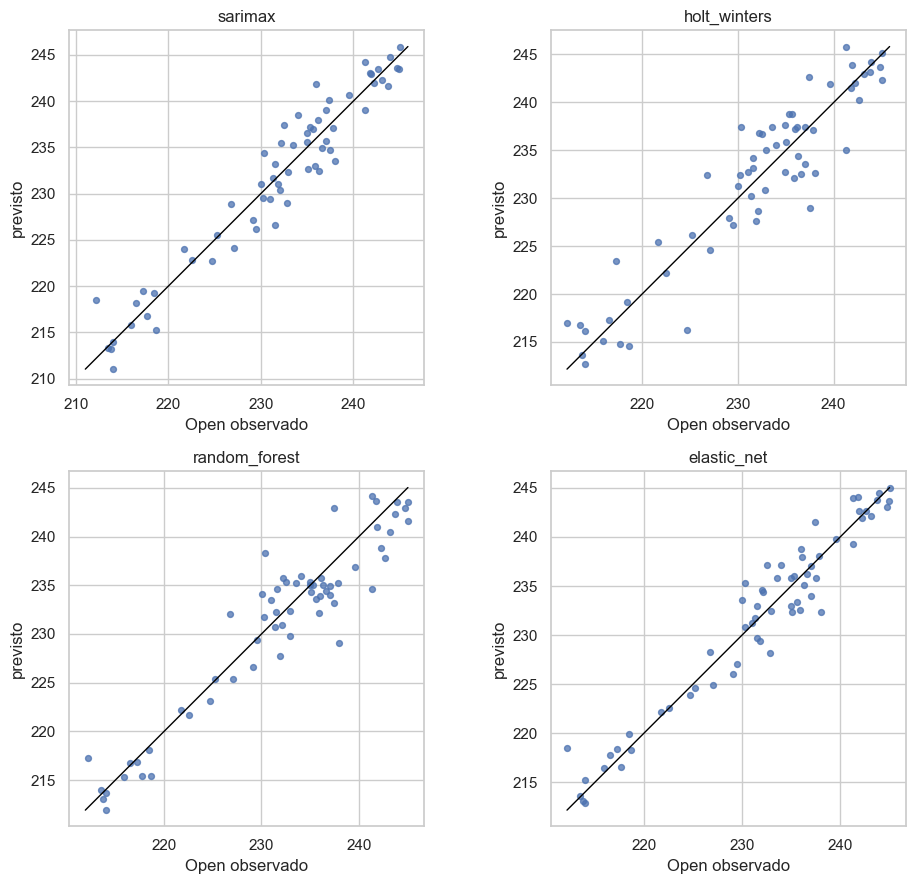

In [12]:
mae_rows = []
for model_name, pred_df in predictions.items():
    score = float(np.mean(np.abs(pred_df["y_true"] - pred_df["y_pred"])))
    mae_rows.append({
        "base_id": BASE_ID,
        "model": model_name,
        "mae": score,
        "n_predictions": len(pred_df),
    })
mae_table = pd.DataFrame(mae_rows).sort_values("mae").reset_index(drop=True)
mae_table["rank"] = np.arange(1, len(mae_table) + 1)
mae_table = mae_table[["base_id", "model", "mae", "rank", "n_predictions"]]
mae_table.to_csv(DATA_DIR / f"mae_{BASE_ID}.csv", index=False)
display(mae_table)
print("Vencedor nesta base:", mae_table.iloc[0]["model"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mae_table["model"], mae_table["mae"], color="#2563eb")
ax.set(ylabel="MAE OOS (USD)", title="Ranking MAE — teste walk-forward")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    pred_df = predictions[model_name]
    ax.plot(pred_df["forecast_date"], pred_df["y_true"], label="Open observado", color="black", linewidth=1.4)
    ax.plot(pred_df["forecast_date"], pred_df["y_pred"], label="previsto", linewidth=1.2)
    ax.set_title(f"{model_name} — MAE={mae_table.loc[mae_table.model==model_name, 'mae'].iloc[0]:.3f}")
    ax.legend(loc="upper left")
fig.suptitle("Avaliação OOS: Open observado vs previsto", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    pred_df = predictions[model_name]
    ax.scatter(pred_df["y_true"], pred_df["y_pred"], s=18, alpha=0.75)
    lo = min(pred_df["y_true"].min(), pred_df["y_pred"].min())
    hi = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set(xlabel="Open observado", ylabel="previsto", title=model_name, aspect="equal")
plt.tight_layout()
plt.show()


Modelos em nível que acompanham rapidamente a forte tendência podem ter vantagem neste horizonte curto. RF tende a interpolar níveis vistos no treino e pode sofrer quando a série alcança novos máximos; Elastic Net combina extrapolação linear, shrinkage e seleção parcial de variáveis, mas depende da estabilidade da relação entre lags e alvo. A conclusão efetiva deve seguir a tabela executada acima.

## H. Resíduos OOS, ACF, PACF e Ljung–Box

Como `h=1` e cada origem avança um pregão, os resíduos formam uma única sequência temporal sem sobreposição entre passos. Além da ACF, a PACF e o histograma mostram se resta estrutura linear ou assimetria.


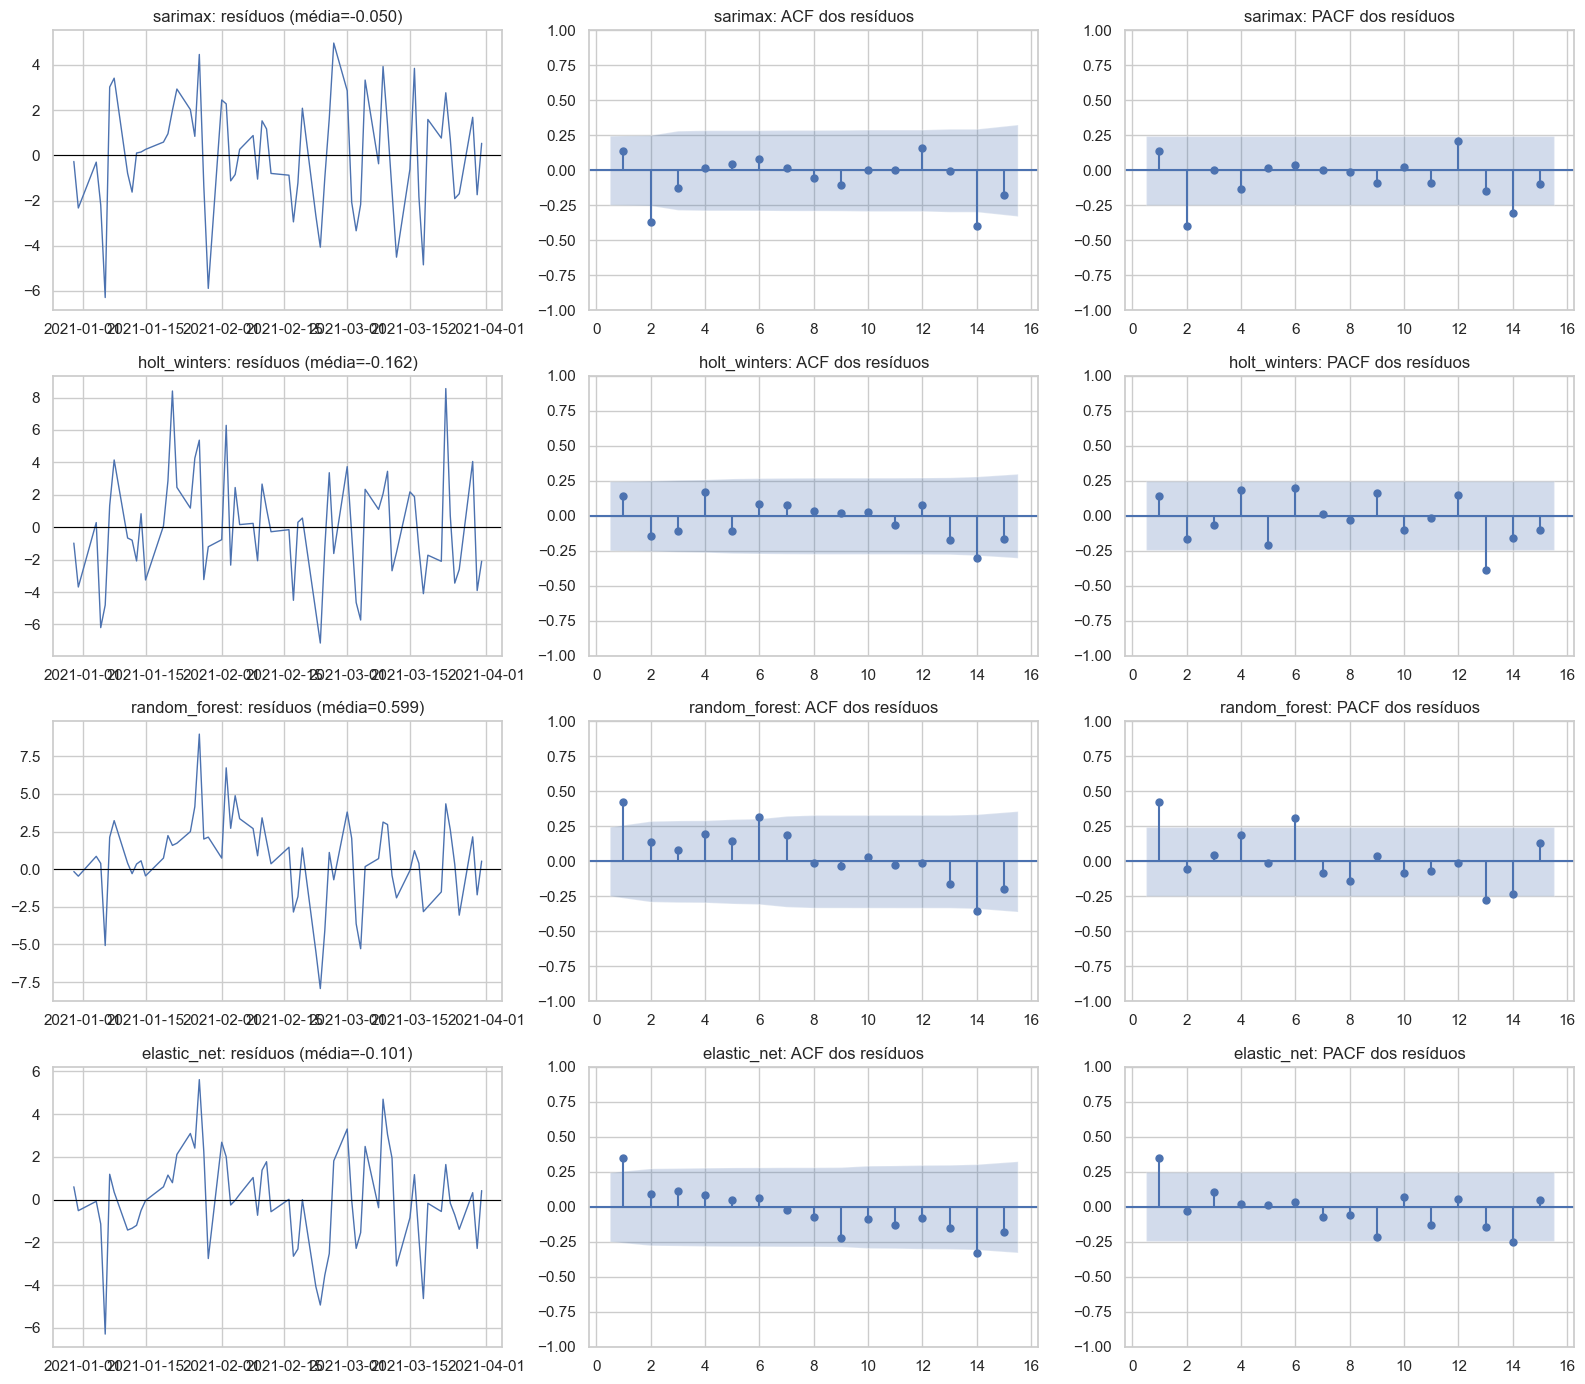

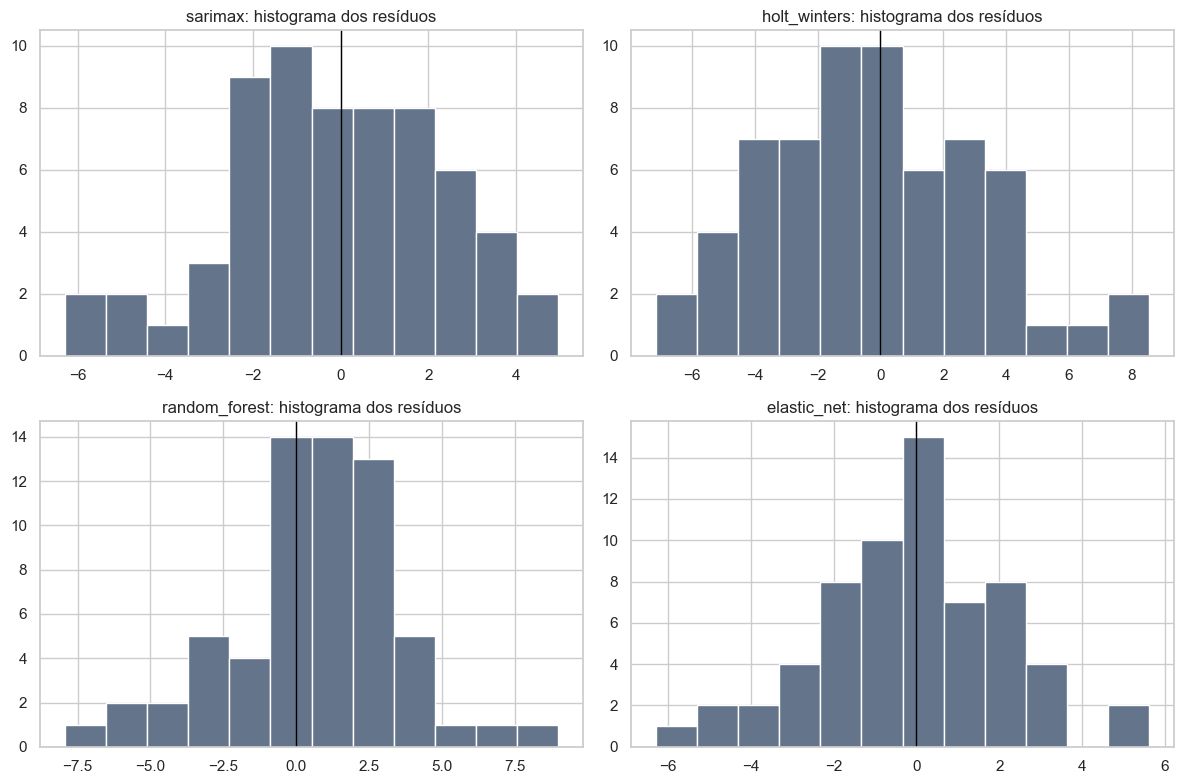

,base_id,model,horizon_step,lag,lb_stat,p_value,n_residuals
0,base_05,sarimax,1,5,11.638141,0.040097,63
1,base_05,sarimax,1,10,13.137347,0.216094,63
2,base_05,holt_winters,1,5,6.384790,0.270556,63
3,base_05,holt_winters,1,10,7.435097,0.683829,63
4,base_05,random_forest,1,5,17.705004,0.003340,63
5,base_05,random_forest,1,10,27.518403,0.002155,63
6,base_05,elastic_net,1,5,10.071080,0.073246,63
7,base_05,elastic_net,1,10,15.033400,0.130849,63


p < 0,05 indica evidência de autocorrelação residual no lag correspondente.


In [13]:
ljung_rows = []
fig, axes = plt.subplots(len(model_names), 3, figsize=(16, 14))
for row_idx, model_name in enumerate(model_names):
    pred_df = predictions[model_name].copy()
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    residual_cols = key_cols + ["y_true", "y_pred", "residual"]
    pred_df[residual_cols].to_csv(DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv", index=False)
    residuals = pred_df["residual"]
    residual_lags = min(15, max(5, len(residuals) // 4))
    axes[row_idx, 0].plot(pred_df["forecast_date"], residuals, linewidth=1)
    axes[row_idx, 0].axhline(0, color="black", linewidth=0.8)
    axes[row_idx, 0].set_title(f"{model_name}: resíduos (média={residuals.mean():.3f})")
    plot_acf(residuals, lags=residual_lags, ax=axes[row_idx, 1], zero=False)
    axes[row_idx, 1].set_title(f"{model_name}: ACF dos resíduos")
    plot_pacf(residuals, lags=residual_lags, ax=axes[row_idx, 2], zero=False, method="ywm")
    axes[row_idx, 2].set_title(f"{model_name}: PACF dos resíduos")
    for lag in [5, 10]:
        lb = acorr_ljungbox(residuals, lags=[lag], return_df=True).iloc[0]
        ljung_rows.append({
            "base_id": BASE_ID,
            "model": model_name,
            "horizon_step": 1,
            "lag": lag,
            "lb_stat": float(lb["lb_stat"]),
            "p_value": float(lb["lb_pvalue"]),
            "n_residuals": len(residuals),
        })
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    residuals = predictions[model_name]["y_true"] - predictions[model_name]["y_pred"]
    ax.hist(residuals, bins=12, color="#64748b", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{model_name}: histograma dos resíduos")
plt.tight_layout()
plt.show()

ljung_table = pd.DataFrame(ljung_rows)
ljung_table.to_csv(DATA_DIR / f"ljung_box_{BASE_ID}.csv", index=False)
display(ljung_table)
print("p < 0,05 indica evidência de autocorrelação residual no lag correspondente.")


A média dos resíduos indica viés (positivo = subprevisão; negativo = sobreprevisão). A série temporal mostra mudanças de variabilidade e choques; a ACF e o Ljung–Box verificam se ainda resta dependência linear. Rejeitar ruído branco em algum modelo sugere dinâmica temporal não capturada, mesmo quando o MAE é competitivo.

## I. Importância e persistência dos modelos finais

Os modelos finais são reajustados com todas as observações disponíveis, depois de congeladas as previsões OOS. O `training_end` registra explicitamente esse uso do período de teste; ele não altera as métricas históricas.

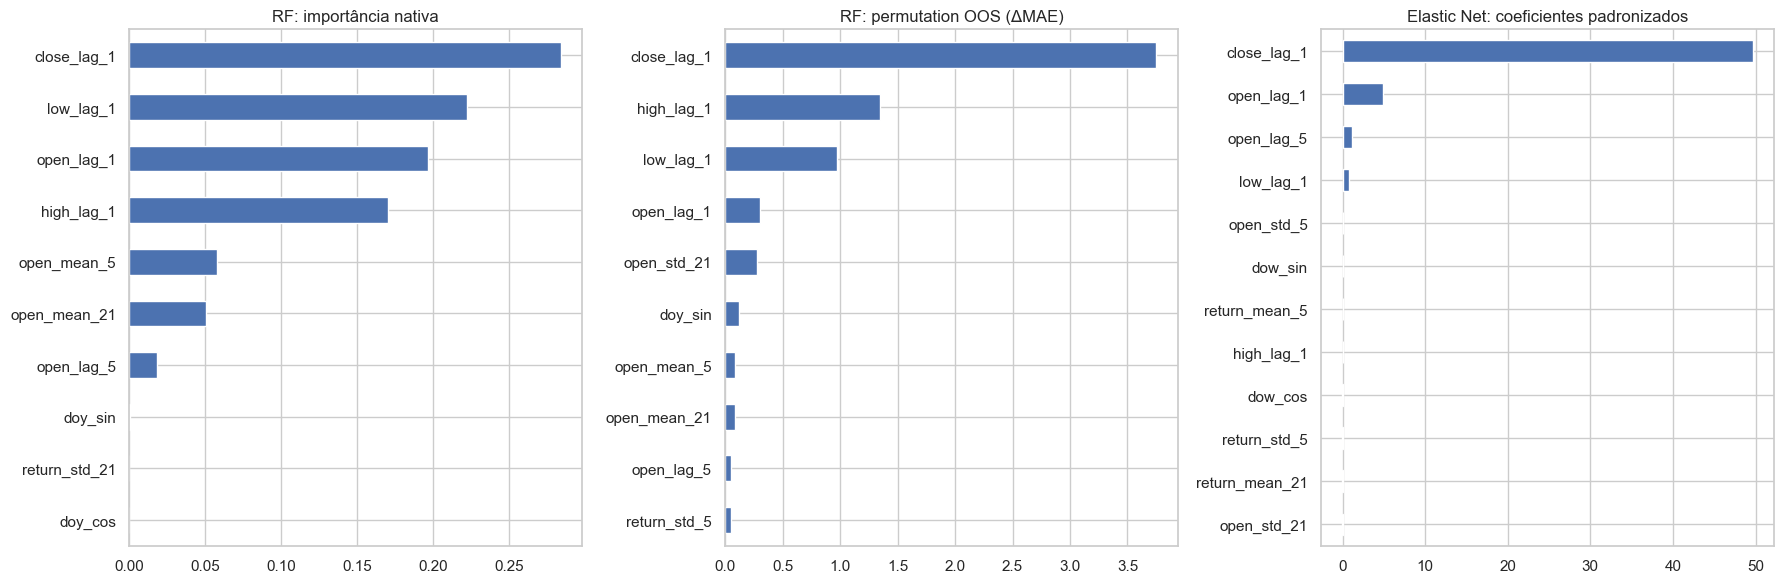

,rf_native,rf_permutation_oos
close_lag_1,0.283780,3.752076
high_lag_1,0.170014,1.349866
low_lag_1,0.222239,0.972034
open_lag_1,0.196609,0.307178
open_std_21,0.000066,0.276729
doy_sin,0.000242,0.119484
open_mean_5,0.057876,0.082939
open_mean_21,0.050512,0.081688
open_lag_5,0.018268,0.054176
return_std_5,0.000033,0.051239


,elastic_net_standardized_coefficient
close_lag_1,49.741097
open_lag_1,4.840490
open_lag_5,1.144167
low_lag_1,0.832881
open_std_21,-0.102216
open_std_5,0.057921
dow_sin,0.038410
return_mean_5,0.027868
return_mean_21,-0.018383
return_std_5,-0.007115


Coeficientes Elastic Net zerados: 7 de 20


,coefficient,p_value
close_lag_1,0.742075,0.000000
log_volume_lag_1,0.071777,0.634635
dow_sin,0.059788,0.160295
dow_cos,-0.029161,0.532181


Holt-Winters: interpretação estrutural por nível/tendência/sazonalidade; não há FI tabular.


In [14]:
full_x = samples[feature_cols]
full_y = samples["target"]

final_rf = clone(rf_base).set_params(**rf_params).fit(full_x, full_y)
final_en = clone(en_base).set_params(**en_params).fit(full_x, full_y)
final_sarimax = SARIMAX(
    full_y,
    exog=samples[sarimax_features],
    order=tuple(sarimax_params["order"]),
    seasonal_order=tuple(sarimax_params["seasonal_order"]),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=75)
final_hw = ExponentialSmoothing(
    full_y.to_numpy(),
    trend=hw_params["trend"],
    damped_trend=hw_params["damped_trend"],
    seasonal=hw_params["seasonal"],
    seasonal_periods=hw_params.get("seasonal_periods"),
    initialization_method="estimated",
).fit(optimized=True)

joblib.dump(final_rf, ARTIFACT_DIR / "random_forest.pkl")
joblib.dump(final_en, ARTIFACT_DIR / "elastic_net.pkl")
with open(ARTIFACT_DIR / "sarimax.pkl", "wb") as f:
    pickle.dump(final_sarimax, f)
with open(ARTIFACT_DIR / "holt_winters.pkl", "wb") as f:
    pickle.dump(final_hw, f)

version_info = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
}
selected_params = {
    "sarimax": sarimax_params,
    "holt_winters": hw_params,
    "random_forest": rf_params,
    "elastic_net": en_params,
}
for model_name in model_names:
    meta = {
        "base_id": BASE_ID,
        "model": model_name,
        "hyperparams": selected_params[model_name],
        "training_end": str(cleaned["Date"].max().date()),
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "horizon": HORIZON,
        "multi_step_strategy": "direct_one_step",
        "versions": version_info,
    }
    with open(ARTIFACT_DIR / f"{model_name}_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

rf_importance = pd.Series(final_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
en_coef = pd.Series(final_en.named_steps["model"].coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)
perm = permutation_importance(
    final_rf,
    test_samples[feature_cols],
    test_samples["target"],
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rf_importance.head(10).sort_values().plot.barh(ax=axes[0], title="RF: importância nativa")
perm_importance.head(10).sort_values().plot.barh(ax=axes[1], title="RF: permutation OOS (ΔMAE)")
en_coef.head(12).sort_values().plot.barh(ax=axes[2], title="Elastic Net: coeficientes padronizados")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"rf_native": rf_importance, "rf_permutation_oos": perm_importance}).sort_values("rf_permutation_oos", ascending=False).head(12))
display(en_coef.rename("elastic_net_standardized_coefficient").to_frame().head(12))
print("Coeficientes Elastic Net zerados:", int((en_coef == 0).sum()), "de", len(en_coef))

sarimax_interpretation = pd.DataFrame({
    "coefficient": final_sarimax.params,
    "p_value": final_sarimax.pvalues,
})
display(sarimax_interpretation.loc[sarimax_interpretation.index.intersection(sarimax_features)])
print("Holt-Winters: interpretação estrutural por nível/tendência/sazonalidade; não há FI tabular.")


### Elastic Net — estudo local

Elastic Net minimiza o erro quadrático com uma penalização que combina L1 e L2. `l1_ratio=1` aproxima Lasso (esparsidade) e `l1_ratio=0` aproxima Ridge (shrinkage distribuído). Padronizar é indispensável porque a penalização depende da escala e porque torna os coeficientes comparáveis. O `StandardScaler` foi ajustado exclusivamente dentro de cada fold/prefixo de treino.

O `alpha` escolhido controla a intensidade total da regularização e o `l1_ratio` selecionado mostra o compromisso observado entre zerar coeficientes e estabilizar variáveis correlacionadas. A comparação com RF é justa porque ambos recebem a mesma matriz. Na interpretação, lags de `Close`/OHLC/volume são informação disponível na origem; não são valores contemporâneos à abertura prevista.

In [15]:
# Validação final de artefatos e contratos.
required_data = [
    DATA_DIR / f"cleaned_{BASE_ID}.csv",
    DATA_DIR / f"features_{BASE_ID}.parquet",
    DATA_DIR / f"mae_{BASE_ID}.csv",
    DATA_DIR / f"ljung_box_{BASE_ID}.csv",
]
for model_name in model_names:
    required_data.extend([
        DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json",
    ])
    assert (ARTIFACT_DIR / f"{model_name}.pkl").exists()
    assert (ARTIFACT_DIR / f"{model_name}_meta.json").exists()
assert all(path.exists() and path.stat().st_size > 0 for path in required_data)

raw_after = pd.read_csv(RAW_FILE)
pd.testing.assert_frame_equal(raw, raw_after)
assert len(mae_table) == 4
assert mae_table["n_predictions"].nunique() == 1
assert np.isfinite(mae_table["mae"]).all()
print(f"VALIDAÇÃO FINAL OK: {len(required_data)} arquivos de dados e 8 artefatos de modelo.")
print("Raw preservado; notebook concluiu sem estado oculto.")

VALIDAÇÃO FINAL OK: 16 arquivos de dados e 8 artefatos de modelo.
Raw preservado; notebook concluiu sem estado oculto.
